In [1]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

%matplotlib inline

In [2]:
#loading dataset
df = pd.read_csv("email_dataset_100k.csv")

In [3]:
df.shape

(100000, 30)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 30 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   raw_text                 100000 non-null  str    
 1   subject                  100000 non-null  str    
 2   body_plain               100000 non-null  str    
 3   body_html                42403 non-null   str    
 4   from_address             100000 non-null  str    
 5   from_domain              100000 non-null  str    
 6   reply_to                 29918 non-null   str    
 7   to_addresses             100000 non-null  str    
 8   cc_addresses             19902 non-null   str    
 9   date                     100000 non-null  str    
 10  hour_of_day              100000 non-null  int64  
 11  message_id               100000 non-null  str    
 12  in_reply_to              14973 non-null   str    
 13  num_received_headers     100000 non-null  int64  
 14  received_origin_

In [6]:
#checking target variable
df['label'].value_counts()

label
0    50000
1    50000
Name: count, dtype: int64

In [5]:
df.describe()

,hour_of_day,num_received_headers,num_urls,num_emails_in_body,num_phone_numbers,x_spam_score,label
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,11.487060,4.507110,0.799700,0.041960,0.634160,4.000137,0.500000
std,6.911186,1.501783,0.871543,0.200499,0.561573,4.319804,0.500003
min,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,11.000000,5.000000,0.500000,0.000000,1.000000,2.000000,0.500000
75%,17.000000,6.000000,2.000000,0.000000,1.000000,8.000000,1.000000
max,23.000000,7.000000,2.000000,1.000000,2.000000,12.000000,1.000000


In [12]:
df.head()

,raw_text,subject,body_plain,body_html,from_address,from_domain,reply_to,to_addresses,cc_addresses,date,...,has_html,num_urls,num_emails_in_body,num_phone_numbers,contains_tracking_token,x_spam_score,user_agent,list_unsubscribe,language,label
0,"Subject: Release notes v2.6.4\nDear Vik,\n\nWe...",Release notes v2.6.4,"Dear Vik,\n\nWe received invoice 765713. It wi...",NaN,leo.wilson@adatum.net,adatum.net,NaN,kathy_taylor@notifications.net,NaN,2024-09-13T16:25:32,...,False,0,0,1,False,0.00,Microsoft Outlook,NaN,en,0
1,"Subject: WINNER! Claim your reward\nDear user,...",WINNER! Claim your reward,"Dear user,\n\nYour parcel has been flagged. To...",NaN,riya_miller313@proton.me,proton.me,NaN,olivia_wilson841@accounts-mail.com,NaN,2024-07-10T01:15:32,...,False,1,0,1,False,4.82,Mutt,NaN,en,1
2,"Subject: Follow-up: onboarding tasks\nHi Zack,...",Follow-up: onboarding tasks,"Hi Zack,\n\nHere are the notes from our meetin...",NaN,wendytaylor@cohosu.org,cohosu.org,NaN,vikwilliams@contoso.com,NaN,2024-04-23T16:20:32,...,False,0,0,0,False,0.00,Apple Mail,NaN,de,0
3,Subject: Limited-time offer: $119 cloud storag...,Limited-time offer: $119 cloud storage,"Attention Bob,\n\nWe detected unusual activity...",<html><body><h3>Limited-time offer: $119 cloud...,vik.brown@outlook.com,outlook.com,carol.johnson@icloud.com,carol.rodriguez@devops.local,NaN,2024-06-07T19:15:32,...,True,2,0,1,False,9.15,Mutt,NaN,it,1
4,"Subject: Weekly update - Legal\nTeam,\n\nNotes...",Weekly update - Legal,"Team,\n\nNotes from Legal daily standup attach...","<p>Team,<br/><br/>Notes from Legal daily stand...",grace_taylor@globalbank.com,globalbank.com,NaN,leo_wilson@notifications.net,NaN,2024-07-05T11:33:32,...,True,0,0,0,False,0.00,Thunderbird,NaN,it,0


In [14]:
df.describe(include='str')

,raw_text,subject,body_plain,body_html,from_address,from_domain,reply_to,to_addresses,cc_addresses,date,message_id,in_reply_to,received_origin_ip,spf_result,dkim_result,dmarc_result,attachment_types,user_agent,list_unsubscribe,language
count,100000,100000,100000,42403,100000,100000,29918,100000,19902,100000,100000,14973,100000,100000,100000,100000,20142,100000,19909,100000
unique,95109,16684,80518,38514,42740,18,15374,42591,19092,99668,100000,14973,100000,3,3,3,20139,13,19909,5
top,"Subject: Draft proposal for review\nHello,\n\n...",Action required: Billing problem,"Hello,\n\nAre you free for lunch tomorrow near...","<p>Hello,<br/><br/>Are you free for lunch tomo...",eve_williams@outlook.com,proton.me,alice.williams@icloud.com,yasmin.garcia@globalbank.com,kathy_brown@bizsupport.co,2025-04-27T16:35:36,<oazqpryu589441@adatum.net>,<bfkcgor40826@hr-mail.net>,155.60.143.1,pass,pass,pass,update_855741.pdf,Apple Mail,https://notify.app/wallet/01093231-sqtas,en
freq,20,3587,184,55,16,7441,12,16,5,3,1,1,1,50035,50208,44899,2,10167,1,60032


In [15]:
df.groupby(['from_domain', 'label']).size().unstack(fill_value=0)

label,0,1
from_domain,,
accounts-mail.com,3225,1667
adatum.net,3282,1678
bizsupport.co,3228,1624
cohosu.org,3282,1602
contoso.com,3287,1697
devops.local,3352,1626
example.com,3220,1625
fabrikam.io,3244,1640
globalbank.com,3339,1557


In [16]:
domain_label_rate = (
    df.groupby('from_domain')['label']
      .mean()
      .sort_values(ascending=False)
)

domain_label_rate

from_domain
icloud.com           0.803984
gmail.com            0.795862
yahoo.com            0.794199
proton.me            0.792367
outlook.com          0.791872
accounts-mail.com    0.340760
contoso.com          0.340490
adatum.net           0.338306
notifications.net    0.336420
fabrikam.io          0.335790
example.com          0.335397
bizsupport.co        0.334707
northwind.com        0.329545
mycompany.com        0.328888
cohosu.org           0.328010
devops.local         0.326637
hr-mail.net          0.324965
globalbank.com       0.318015
Name: label, dtype: float64

In [7]:
df['label'].value_counts(normalize=True) * 100

label
0    50.0
1    50.0
Name: proportion, dtype: float64

In [8]:
#checking missing values
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

missing

in_reply_to         85027
cc_addresses        80098
list_unsubscribe    80091
attachment_types    79858
reply_to            70082
body_html           57597
dtype: int64

In [9]:
#check duplicates
df.duplicated().sum()

np.int64(0)

In [10]:
#check duplicate messages
df['message_id'].duplicated().sum()

np.int64(0)

In [11]:
#check data type
df.dtypes

raw_text                       str
subject                        str
body_plain                     str
body_html                      str
from_address                   str
from_domain                    str
reply_to                       str
to_addresses                   str
cc_addresses                   str
date                           str
hour_of_day                  int64
message_id                     str
in_reply_to                    str
num_received_headers         int64
received_origin_ip             str
spf_result                     str
dkim_result                    str
dmarc_result                   str
has_attachments               bool
attachment_types               str
has_html                      bool
num_urls                     int64
num_emails_in_body           int64
num_phone_numbers            int64
contains_tracking_token       bool
x_spam_score               float64
user_agent                     str
list_unsubscribe               str
language            

In [22]:
# checking whether the email authentication features are associated with the target.
pd.crosstab(df['spf_result'], df['label'])


label,0,1
spf_result,,
fail,4938,25020
neutral,4907,15100
pass,40155,9880


In [23]:
pd.crosstab(df['dkim_result'], df['label'])

label,0,1
dkim_result,,
fail,4885,24862
neutral,4972,15073
pass,40143,10065


In [21]:
pd.crosstab(df['dmarc_result'], df['label'])

label,0,1
dmarc_result,,
fail,5147,19852
none,9990,20112
pass,34863,10036


In [24]:
#examining whether numerical characteristics differ between label 0 and label 1.
df.groupby('label')[[
    'num_urls',
    'num_emails_in_body',
    'num_phone_numbers',
    'num_received_headers',
    'x_spam_score'
]].mean()

,num_urls,num_emails_in_body,num_phone_numbers,num_received_headers,x_spam_score
label,,,,,
0,0.0000,0.00000,0.18496,5.00954,0.000000
1,1.5994,0.08392,1.08336,4.00468,8.000274


In [25]:
#examining the three Boolean variables
df.groupby('label')[[
    'has_attachments',
    'has_html',
    'contains_tracking_token'
]].mean()

,has_attachments,has_html,contains_tracking_token
label,,,
0,0.15132,0.24866,0.04994
1,0.25152,0.59940,0.60360


In [27]:
# handling missing values by replacing them with an empty string
text_cols = [
    'in_reply_to',
    'cc_addresses',
    'list_unsubscribe',
    'attachment_types',
    'reply_to',
    'body_html'
]

df[text_cols] = df[text_cols].fillna('')

In [28]:
df.isnull().sum()

raw_text                   0
subject                    0
body_plain                 0
body_html                  0
from_address               0
from_domain                0
reply_to                   0
to_addresses               0
cc_addresses               0
date                       0
hour_of_day                0
message_id                 0
in_reply_to                0
num_received_headers       0
received_origin_ip         0
spf_result                 0
dkim_result                0
dmarc_result               0
has_attachments            0
attachment_types           0
has_html                   0
num_urls                   0
num_emails_in_body         0
num_phone_numbers          0
contains_tracking_token    0
x_spam_score               0
user_agent                 0
list_unsubscribe           0
language                   0
label                      0
dtype: int64

In [29]:
#combining the email subject and plain-text body
df['text'] = df['subject'] + ' ' + df['body_plain']

In [30]:
df[['subject', 'body_plain', 'text']].head()

,subject,body_plain,text
0,Release notes v2.6.4,"Dear Vik,\n\nWe received invoice 765713. It wi...","Release notes v2.6.4 Dear Vik,\n\nWe received ..."
1,WINNER! Claim your reward,"Dear user,\n\nYour parcel has been flagged. To...","WINNER! Claim your reward Dear user,\n\nYour p..."
2,Follow-up: onboarding tasks,"Hi Zack,\n\nHere are the notes from our meetin...","Follow-up: onboarding tasks Hi Zack,\n\nHere a..."
3,Limited-time offer: $119 cloud storage,"Attention Bob,\n\nWe detected unusual activity...",Limited-time offer: $119 cloud storage Attenti...
4,Weekly update - Legal,"Team,\n\nNotes from Legal daily standup attach...","Weekly update - Legal Team,\n\nNotes from Lega..."


In [31]:
#checking duplicates text entries
df['text'].duplicated().sum()


np.int64(4891)

In [32]:
df.groupby('text')['label'].nunique().value_counts()

label
1    95109
Name: count, dtype: int64

In [33]:
#removeing duplicate emails text
df = df.drop_duplicates(subset='text').reset_index(drop=True)

In [34]:
#checking shape after removing duplicates email text
df.shape

(95109, 31)

In [35]:
#I will use 80% for training and 20% for testing, while keeping the label proportions consistent
from sklearn.model_selection import train_test_split

X = df['text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [36]:
print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (76087,)
Testing: (19022,)


In [37]:
#Convert text to TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    max_features=50000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [38]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(76087, 50000)
(19022, 50000)


In [39]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)

model.fit(X_train_tfidf, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [40]:
y_pred = model.predict(X_test_tfidf)

In [41]:
# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Calculate model performance metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Display the performance results
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# Display the confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Display the complete classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Confusion Matrix:
[[ 9022     0]
 [    0 10000]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9022
           1       1.00      1.00      1.00     10000

    accuracy                           1.00     19022
   macro avg       1.00      1.00      1.00     19022
weighted avg       1.00      1.00      1.00     19022



In [42]:
# Check whether the target label appears directly in the email text
import re

# Count occurrences of the words "spam" and "ham" in the dataset text
print("spam mentions:", df['text'].str.lower().str.contains(r'\bspam\b').sum())
print("ham mentions:", df['text'].str.lower().str.contains(r'\bham\b').sum())

spam mentions: 0
ham mentions: 0


In [43]:
# Check for overlapping email text between training and testing data
overlap = set(X_train).intersection(set(X_test))

print("Overlapping texts:", len(overlap))

Overlapping texts: 0


In [44]:
# Import ROC-AUC metric
from sklearn.metrics import roc_auc_score

# Get prediction probabilities for the positive class
y_prob = model.predict_proba(X_test_tfidf)[:, 1]

# Calculate ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob)

# Display ROC-AUC
print("ROC-AUC:", roc_auc)

ROC-AUC: 1.0


In [45]:
# Get the words/features used by the TF-IDF vectorizer
feature_names = tfidf.get_feature_names_out()

# Get the Logistic Regression coefficients
coefficients = model.coef_[0]

# Get the 20 features most strongly associated with label 1
top_positive = coefficients.argsort()[-20:][::-1]

# Get the 20 features most strongly associated with label 0
top_negative = coefficients.argsort()[:20]

# Display features associated with label 1
print("Top features associated with Label 1:")
for i in top_positive:
    print(feature_names[i], coefficients[i])

# Display features associated with label 0
print("\nTop features associated with Label 0:")
for i in top_negative:
    print(feature_names[i], coefficients[i])

Top features associated with Label 1:
https 6.312247221958328
ref 5.442256487374974
verify 4.690102137734383
account 4.110675625528609
billing 3.6978131509600303
offer 3.533644669016654
confirm 3.490733111341762
id 3.0115107014020515
parcel 2.9242268759694094
login 2.8018853504663395
limited 2.7758351424001027
info 2.489939673222821
track 2.3439265533144273
security 2.3252423094578676
secure 2.2888063190039563
subscription 2.266697980236926
com 2.2426419602498218
wallet 2.2078005531101126
credit 2.1669579687037195
approved 2.1669579687037195

Top features associated with Label 0:
thanks -4.975325357382238
review -4.632507116781271
notes -4.253949999116594
weekly -3.8566477229475704
best -3.6500771228947904
attached -3.6025030377693597
hi -3.1464404135160002
order -2.995981188455622
shipped -2.995981188455622
2024 -2.849249269308621
let -2.7708917665427464
know -2.7708917665427464
2025 -2.7519604117043595
draft -2.6330837786464425
proposal -2.6330837786464425
standup -2.616199167874414


In [ ]:
#building second model

In [46]:
# Import the Multinomial Naive Bayes classifier
from sklearn.naive_bayes import MultinomialNB

# Create the Naive Bayes model
nb_model = MultinomialNB()

# Train the model using the TF-IDF training data
nb_model.fit(X_train_tfidf, y_train)

# Generate predictions on the test data
nb_pred = nb_model.predict(X_test_tfidf)

# Calculate performance metrics
nb_accuracy = accuracy_score(y_test, nb_pred)
nb_precision = precision_score(y_test, nb_pred)
nb_recall = recall_score(y_test, nb_pred)
nb_f1 = f1_score(y_test, nb_pred)

# Display the results
print("Naive Bayes Accuracy:", nb_accuracy)
print("Naive Bayes Precision:", nb_precision)
print("Naive Bayes Recall:", nb_recall)
print("Naive Bayes F1 Score:", nb_f1)

Naive Bayes Accuracy: 1.0
Naive Bayes Precision: 1.0
Naive Bayes Recall: 1.0
Naive Bayes F1 Score: 1.0


In [47]:
# Get prediction probabilities for Label 1
nb_prob = nb_model.predict_proba(X_test_tfidf)[:, 1]

# Calculate ROC-AUC
nb_roc_auc = roc_auc_score(y_test, nb_prob)

# Display ROC-AUC
print("Naive Bayes ROC-AUC:", nb_roc_auc)

Naive Bayes ROC-AUC: 1.0


In [48]:
# Import cross-validation tools
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation using the training data
cv_scores = cross_val_score(
    model,
    X_train_tfidf,
    y_train,
    cv=5,
    scoring='accuracy'
)

# Display accuracy for each fold
print("Cross-validation accuracy:", cv_scores)

# Display the average accuracy
print("Mean cross-validation accuracy:", cv_scores.mean())

Cross-validation accuracy: [1. 1. 1. 1. 1.]
Mean cross-validation accuracy: 1.0


In [49]:
# Create a summary of the model performance
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes'],
    'Accuracy': [accuracy, nb_accuracy],
    'Precision': [precision, nb_precision],
    'Recall': [recall, nb_recall],
    'F1 Score': [f1, nb_f1],
    'ROC-AUC': [roc_auc, nb_roc_auc]
})

# Display the model comparison
results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,1.0,1.0,1.0,1.0,1.0
1,Naive Bayes,1.0,1.0,1.0,1.0,1.0


In [50]:
# Check whether the spam score is directly determined by the label
pd.crosstab(df['x_spam_score'], df['label'])

label,0,1
x_spam_score,,
0.00,45109,0
4.00,0,31
4.01,0,56
4.02,0,51
4.03,0,49
...,...,...
11.96,0,64
11.97,0,51
11.98,0,57


In [ ]:
#graphical representation:

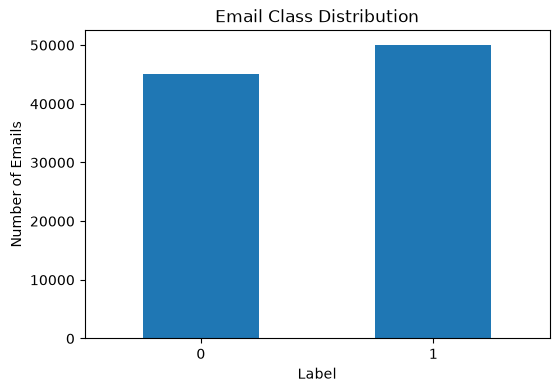

In [51]:
# Plot the number of emails in each class
import matplotlib.pyplot as plt

df['label'].value_counts().sort_index().plot(
    kind='bar',
    figsize=(6, 4)
)

plt.title('Email Class Distribution')
plt.xlabel('Label')
plt.ylabel('Number of Emails')
plt.xticks(rotation=0)
plt.show()

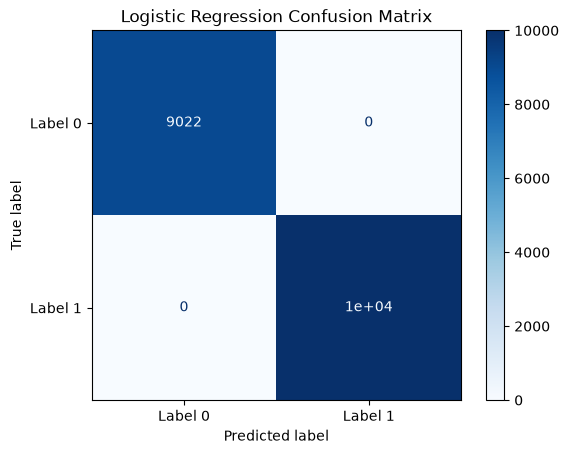

In [52]:
# Create and display the confusion matrix for Logistic Regression
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['Label 0', 'Label 1'],
    cmap='Blues'
)

plt.title('Logistic Regression Confusion Matrix')
plt.show()

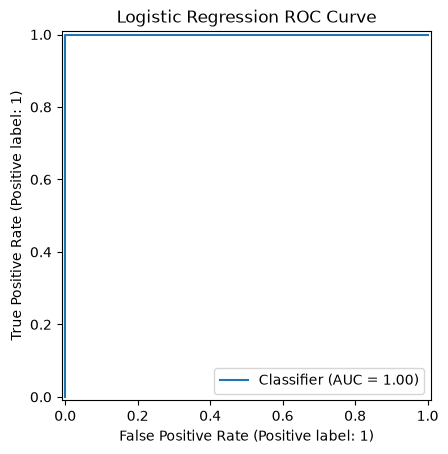

In [53]:
# Plot the ROC curve for Logistic Regression
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title('Logistic Regression ROC Curve')
plt.show()

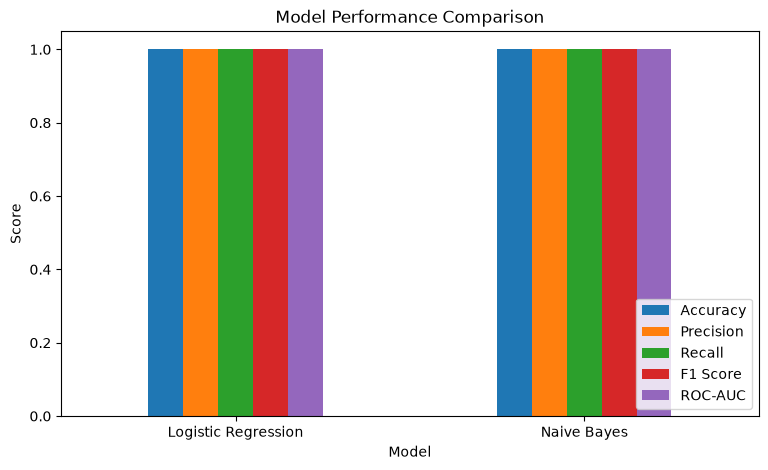

In [54]:
# Plot model performance comparison
results.set_index('Model')[
    ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
].plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Model Performance Comparison')
plt.xlabel('Model')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

In [55]:
# Display the final model performance results
results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,1.0,1.0,1.0,1.0,1.0
1,Naive Bayes,1.0,1.0,1.0,1.0,1.0


In [ ]:
## Model Interpretation
Two machine learning algorithms, Logistic Regression and Multinomial Naive Bayes, were evaluated for email classification. Both models achieved an accuracy, precision, recall and F1-score of 1.00, with an ROC-AUC of 1.00.

The confusion matrix for Logistic Regression showed 9,022 correctly classified Label 0 emails and 10,000 correctly classified Label 1 emails, with zero false positives and zero false negatives.

The TF-IDF analysis also identified meaningful words associated with the two classes. Terms such as verify, account, billing, offer, login and security were strongly associated with Label 1, while terms such as meeting, calendar, reminder, proposal and weekly were associated with Label 0.

The dataset also contains an x_spam_score variable that has an almost deterministic relationship with the target label. This variable was therefore excluded from the predictive text models because it represents information that could directly reveal the target classification.

Although the models achieved perfect performance, the results should be interpreted with caution because the dataset appears to have very strong separation between the two classes. Performance on a different, real-world email dataset may therefore be lower.

In [ ]:
##Conclusion
This project developed an email spam classification system using natural language processing and machine learning. The email subject and body were combined and converted into numerical features using TF-IDF. Logistic Regression and Multinomial Naive Bayes were then trained and evaluated.

Both models achieved perfect results on the test dataset, with 100% accuracy, precision, recall and F1-score and an ROC-AUC of 1.00.

The analysis demonstrated that machine learning can identify patterns in email text that distinguish the two classes. However, because the dataset shows unusually strong class separation, the results should not be assumed to represent performance on all real-world emails.

Overall, the project demonstrates a complete data science workflow: data preparation, exploratory analysis, feature engineering, machine learning, model evaluation, visualization and interpretation.

In [56]:
# Save the trained Logistic Regression model
import joblib

joblib.dump(model, 'spam_detection_model.pkl')

print("Model saved successfully.")

Model saved successfully.


In [57]:
# Save the TF-IDF vectorizer
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

print("TF-IDF vectorizer saved successfully.")

TF-IDF vectorizer saved successfully.


In [58]:
# Function to predict whether a new email belongs to Label 0 or Label 1

def predict_email(email_text):
    
    # Convert the email text into TF-IDF features
    email_tfidf = tfidf.transform([email_text])
    
    # Make the prediction
    prediction = model.predict(email_tfidf)[0]
    
    # Get the prediction probability
    probability = model.predict_proba(email_tfidf)[0].max()
    
    # Display the result
    print("Predicted Label:", prediction)
    print("Confidence:", round(probability * 100, 2), "%")
    
    return prediction

In [59]:
# Test the spam detector with a new email

test_email = """
Congratulations! You have been selected for a special reward.
Verify your account now and claim your limited offer.
Click the link below to receive your prize.
"""

predict_email(test_email)

Predicted Label: 1
Confidence: 99.96 %


np.int64(1)

In [60]:
# Test the model with another email

test_email_2 = """
Hi Thando,

Please find the meeting notes attached.
Our weekly meeting is scheduled for tomorrow at 10:00.
Please review the proposal before the meeting.

Regards
"""

predict_email(test_email_2)

Predicted Label: 0
Confidence: 99.86 %


np.int64(0)